In [1]:
!pip install qiskit-aer
!pip install pylatexenc

In [2]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator

# Build teleportation circuit
qc = QuantumCircuit(3, 2)
qc.h(1); qc.cx(1, 2)        # Bell pair
qc.cx(0, 1); qc.h(0)        # Bell measurement
qc.measure([0, 1], [0, 1])
qc.cx(1, 2); qc.cz(0, 2)    # Correction

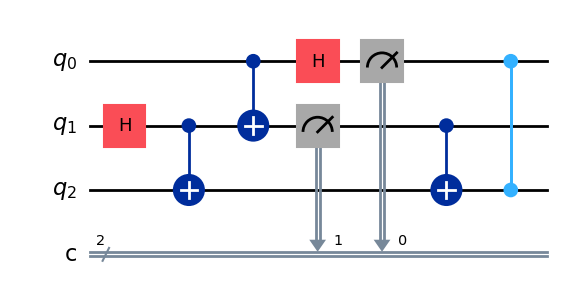

In [3]:
qc.draw("mpl")

Text(0.5, 1.0, 'BB84: Eavesdropping detection')

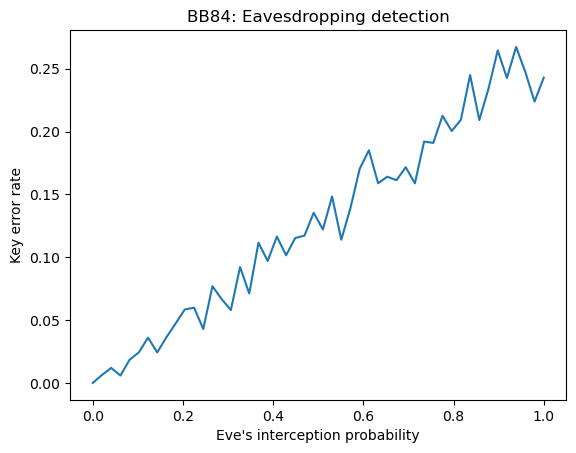

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def bb84_simulate(n_bits=1000, eve_probability=0.0):
    # Alice's bits and bases
    alice_bits = np.random.randint(2, size=n_bits)
    alice_bases = np.random.randint(2, size=n_bits)  # 0=Z, 1=X
    
    # Bob's bases
    bob_bases = np.random.randint(2, size=n_bits)
    
    # Eve intercepts with given probability
    eve_intercepts = np.random.random(n_bits) < eve_probability
    eve_bases = np.random.randint(2, size=n_bits)
    
    # After interception, qubits disturbed where Eve used wrong basis
    disturbed = eve_intercepts & (eve_bases != alice_bases)
    
    # Bob's measurements
    bob_bits = alice_bits.copy()
    bob_bits[disturbed] = np.random.randint(2, size=disturbed.sum())
    
    # Sifted key: where Alice and Bob used same basis
    matching = alice_bases == bob_bases
    alice_key = alice_bits[matching]
    bob_key = bob_bits[matching]
    
    error_rate = np.mean(alice_key != bob_key)
    return error_rate

# Plot error rate vs interception probability
probs = np.linspace(0, 1, 50)
errors = [bb84_simulate(eve_probability=p) for p in probs]
plt.plot(probs, errors)
plt.xlabel("Eve's interception probability")
plt.ylabel("Key error rate")
plt.title("BB84: Eavesdropping detection")

In [5]:
!pip install qiskit qiskit-aer qiskit-nature scipy matplotlib

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 6.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [qiskit-algorithms]
   ---------------------------------------- 0/2 [qiskit-algorithms]
   -------------------- ------------------- 1/2 [qiskit-nature]
   -------------------- ------------------- 1/2 [qiskit-nature]
   -------------------- ------------------- 1/2 [qiskit-nature]
   -------------------- ------------------- 1/2 [qiskit-nature]
   ---------------------------------------- 2/2 [qiskit-nature]



In [6]:
import numpy as np

# H2 Hamiltonian in STO-3G basis (Jordan-Wigner mapped, simplified)
# Coefficients from PySCF or hardcoded from literature at R=0.74 Angstrom
# H = c0*I + c1*Z0 + c2*Z1 + c3*Z0Z1 + c4*X0X1 + c5*Y0Y1

def pauli_I(): return np.eye(2)
def pauli_X(): return np.array([[0,1],[1,0]])
def pauli_Y(): return np.array([[0,-1j],[1j,0]])
def pauli_Z(): return np.array([[1,0],[0,-1]])

def kron(a, b): return np.kron(a, b)

# Build 4x4 Hamiltonian for 2 qubits at R=0.735 Angstrom
c0, c1, c2, c3, c4, c5 = -1.0523, 0.3979, -0.3979, -0.0112, 0.1809, 0.1809

H = (c0 * kron(pauli_I(), pauli_I()) +
     c1 * kron(pauli_Z(), pauli_I()) +
     c2 * kron(pauli_I(), pauli_Z()) +
     c3 * kron(pauli_Z(), pauli_Z()) +
     c4 * kron(pauli_X(), pauli_X()) +
     c5 * kron(pauli_Y(), pauli_Y()))

eigenvalues = np.linalg.eigvalsh(H)
print(f"Ground state energy (exact): {eigenvalues[0]:.6f} Ha")

Ground state energy (exact): -1.915284 Ha


In [17]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from scipy.optimize import minimize
import numpy as np

# Define Hamiltonian as SparsePauliOp
hamiltonian = SparsePauliOp.from_list([
    ("II", -1.0523),
    ("IZ",  0.3979),
    ("ZI", -0.3979),
    ("ZZ", -0.0112),
    ("XX",  0.1809),
    ("YY",  0.1809),
])

# Hardware-efficient ansatz (UCCSD-inspired, 2 parameters)
def build_ansatz(theta):
    qc = QuantumCircuit(2)
    qc.x(0)                  # |10> reference state (HF state)
    qc.ry(theta[0], 0)
    qc.ry(theta[1], 1)
    qc.cx(0, 1)
    return qc

energy_history = []

# Cost function
estimator = StatevectorEstimator()
def cost(theta):
    qc = build_ansatz(theta)
    job = estimator.run([(qc, hamiltonian)])
    
    energy = job.result()[0].data.evs
    
    energy_history.append(energy)
    
    return energy

# Optimize
result = minimize(cost, x0=[0.1, 0.1], method='COBYLA',
                  options={'maxiter': 500})

print(f"VQE ground state energy: {result.fun:.6f} Ha")
print(f"Exact energy:            -1.137270 Ha")

VQE ground state energy: -1.915284 Ha
Exact energy:            -1.137270 Ha


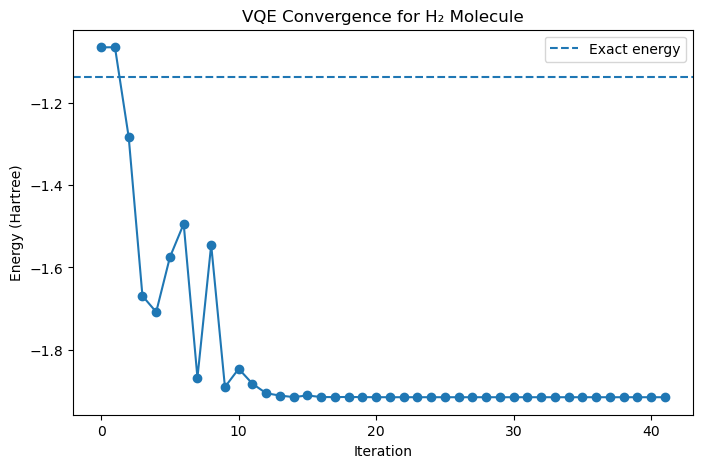

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(energy_history, marker='o')
plt.axhline(-1.137270, linestyle='--', label='Exact energy')

plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("VQE Convergence for H₂ Molecule")
plt.legend()

plt.show()

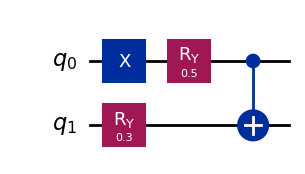

In [19]:
qc = build_ansatz([0.5, 0.3])
qc.draw("mpl")